# SED Reasoning Dataset Analysis

Comprehensive analysis of the SED reasoning dataset for LLM evaluation. This notebook explores dataset composition, difficulty distribution, generator diversity, and key characteristics that impact puzzle complexity.


In [67]:
import json
import seaborn as sns
from pathlib import Path
from collections import Counter

# Professional styling
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('seaborn-whitegrid')
        
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['figure.dpi'] = 100

# Color scheme
COLORS = {
    'easy': '#2ecc71',
    'medium': '#f39c12', 
    'hard': '#e74c3c',
    'expert': '#9b59b6'
}

# Load metadata
data_dir = Path("../data")
with open(data_dir / "metadata.json", "r") as f:
    metadata = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(metadata)

print(f"📊 Dataset Overview")
print(f"{'='*60}")
print(f"Total Problems: {len(df)}")
print(f"Generator Types: {df['generator'].nunique()}")
print(f"Difficulty Levels: {df['difficulty_level'].nunique()}")
print(f"{'='*60}\n")


📊 Dataset Overview
Total Problems: 100
Generator Types: 8
Difficulty Levels: 3



### Difficulty Distribution in Dataset


/var/folders/1j/6n9mdv5j1zv3pd80zp_xh8mr0000gn/T/ipykernel_89371/4289613406.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


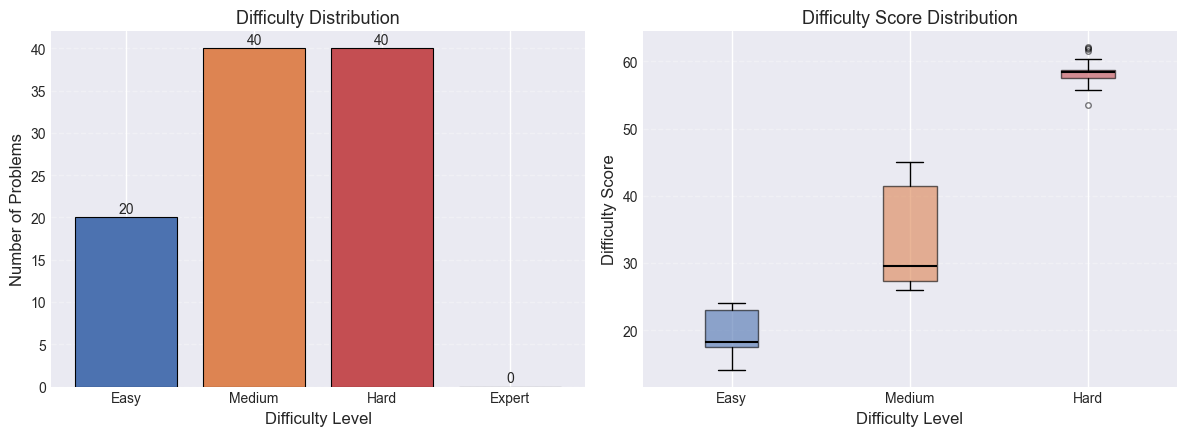

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Order
difficulty_order = ['easy', 'medium', 'hard', 'expert']

# Counts
difficulty_counts = (
    df['difficulty_level']
    .value_counts()
    .reindex(difficulty_order, fill_value=0)
)

# Boxplot data
box_data = [
    df[df['difficulty_level'] == level]['difficulty_score']
    for level in difficulty_order
    if level in df['difficulty_level'].values
]
box_labels = [
    level.capitalize()
    for level in difficulty_order
    if level in df['difficulty_level'].values
]

# Classic color palette (journal-safe)
BAR_COLORS = ['#4C72B0', '#DD8452', '#C44E52', '#8172B2']  # muted blue/orange/red/purple

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# -------------------------
# Bar plot (left)
# -------------------------
axes[0].bar(
    difficulty_counts.index.str.capitalize(),
    difficulty_counts.values,
    color=BAR_COLORS[:len(difficulty_counts)],
    edgecolor='black',
    linewidth=0.8
)

axes[0].set_title("Difficulty Distribution", fontsize=13)
axes[0].set_ylabel("Number of Problems")
axes[0].set_xlabel("Difficulty Level")
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].set_axisbelow(True)

# Add counts on top
for i, val in enumerate(difficulty_counts.values):
    axes[0].text(i, val + 0.5, str(val), ha='center', fontsize=10)

# -------------------------
# Box plot (right)
# -------------------------
bp = axes[1].boxplot(
    box_data,
    labels=box_labels,
    patch_artist=True,
    boxprops=dict(facecolor='white', edgecolor='black'),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

# Light fill for boxes
for patch, color in zip(bp['boxes'], BAR_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_title("Difficulty Score Distribution", fontsize=13)
axes[1].set_xlabel("Difficulty Level")
axes[1].set_ylabel("Difficulty Score")
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


### Generator Type Distribution


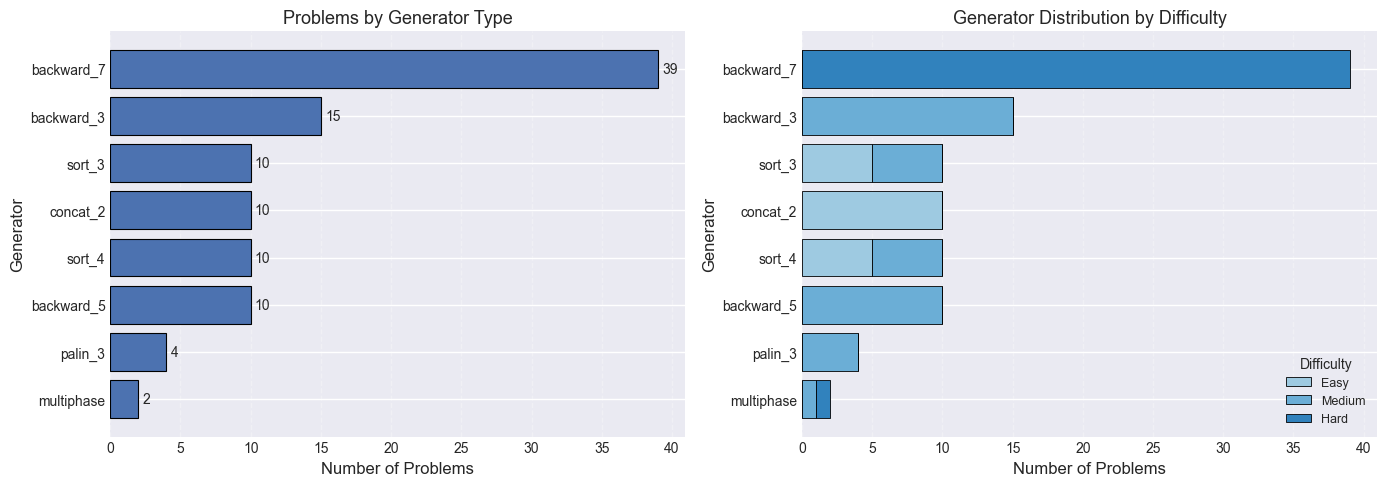

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# Generator counts
generator_counts = df['generator'].value_counts().sort_values()

# Difficulty breakdown per generator
generator_difficulty = pd.crosstab(df['generator'], df['difficulty_level'])
generator_difficulty = generator_difficulty.reindex(generator_counts.index)

difficulty_order = [d for d in ['easy', 'medium', 'hard', 'expert']
                    if d in generator_difficulty.columns]

# Classic, muted colors (print-safe)
GEN_COLOR = '#4C72B0'  # muted blue
DIFF_COLORS = {
    'easy':   '#9ECAE1',  # light blue
    'medium': '#6BAED6',
    'hard':   '#3182BD',
    'expert': '#08519C'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Left: Generator counts
# -------------------------
axes[0].barh(
    generator_counts.index,
    generator_counts.values,
    color=GEN_COLOR,
    edgecolor='black',
    linewidth=0.8
)

axes[0].set_title("Problems by Generator Type", fontsize=13)
axes[0].set_xlabel("Number of Problems")
axes[0].set_ylabel("Generator")
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
axes[0].set_axisbelow(True)

# Value labels
for i, val in enumerate(generator_counts.values):
    axes[0].text(val + 0.3, i, str(val), va='center', fontsize=10)

# -------------------------
# Right: Difficulty breakdown
# -------------------------
left = [0] * len(generator_difficulty)

for level in difficulty_order:
    values = generator_difficulty[level].values
    axes[1].barh(
        generator_difficulty.index,
        values,
        left=left,
        color=DIFF_COLORS[level],
        edgecolor='black',
        linewidth=0.6,
        label=level.capitalize()
    )
    left = [l + v for l, v in zip(left, values)]

axes[1].set_title("Generator Distribution by Difficulty", fontsize=13)
axes[1].set_xlabel("Number of Problems")
axes[1].set_ylabel("Generator")
axes[1].grid(axis='x', linestyle='--', alpha=0.3)
axes[1].set_axisbelow(True)

axes[1].legend(
    title="Difficulty",
    fontsize=9,
    title_fontsize=10,
    frameon=False
)

plt.tight_layout()
plt.show()



### Solution Length vs Difficulty


/var/folders/1j/6n9mdv5j1zv3pd80zp_xh8mr0000gn/T/ipykernel_89371/1574153205.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


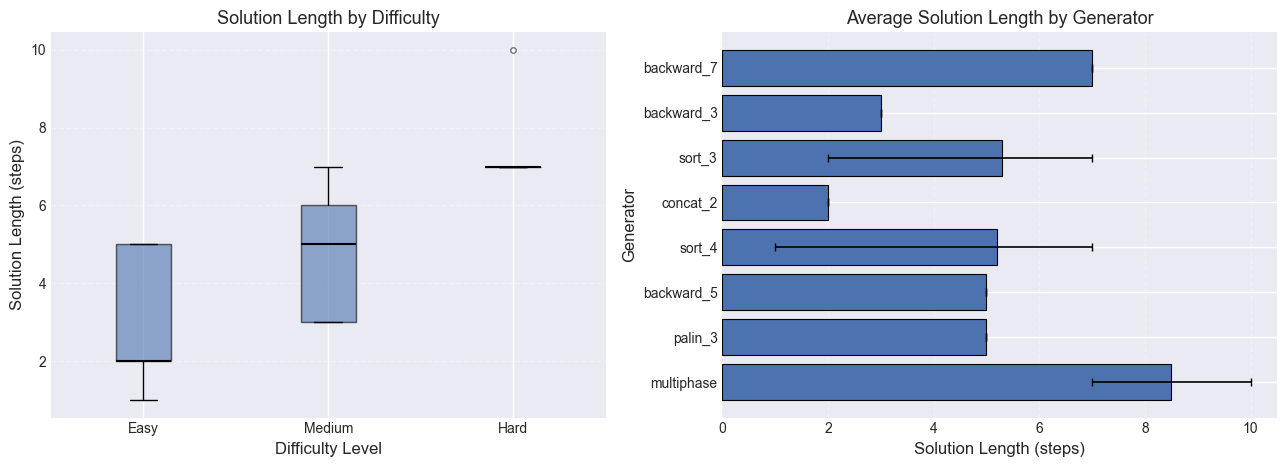

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Ordering
difficulty_order = ['easy', 'medium', 'hard', 'expert']
difficulty_order_plot = [d for d in difficulty_order if d in df['difficulty_level'].values]

# Data for boxplot
box_data = [
    df[df['difficulty_level'] == level]['solution_length']
    for level in difficulty_order_plot
]

# Generator summary
generator_sol = (
    df.groupby('generator')['solution_length']
      .agg(['mean', 'min', 'max'])
      .round(1)
)
generator_sol = generator_sol.reindex(generator_counts.index)

# Classic colors
BOX_COLOR = '#4C72B0'      # muted blue
BAR_COLOR = '#4C72B0'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# -------------------------------------------------
# Left: Solution length by difficulty (boxplot)
# -------------------------------------------------
bp = axes[0].boxplot(
    box_data,
    labels=[d.capitalize() for d in difficulty_order_plot],
    patch_artist=True,
    boxprops=dict(facecolor='white', edgecolor='black'),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

# Light fill
for patch in bp['boxes']:
    patch.set_facecolor(BOX_COLOR)
    patch.set_alpha(0.6)

axes[0].set_title("Solution Length by Difficulty", fontsize=13)
axes[0].set_xlabel("Difficulty Level")
axes[0].set_ylabel("Solution Length (steps)")
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].set_axisbelow(True)

# -------------------------------------------------
# Right: Average solution length by generator
# -------------------------------------------------
y_pos = np.arange(len(generator_sol))

axes[1].barh(
    y_pos,
    generator_sol['mean'],
    color=BAR_COLOR,
    edgecolor='black',
    linewidth=0.8
)

# Error bars (min–max range)
for i, row in enumerate(generator_sol.itertuples()):
    axes[1].errorbar(
        row.mean,
        i,
        xerr=[[row.mean - row.min], [row.max - row.mean]],
        fmt='none',
        ecolor='black',
        elinewidth=1.2,
        capsize=3
    )

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(generator_sol.index)
axes[1].set_title("Average Solution Length by Generator", fontsize=13)
axes[1].set_xlabel("Solution Length (steps)")
axes[1].set_ylabel("Generator")
axes[1].grid(axis='x', linestyle='--', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


### Complexity Relationships


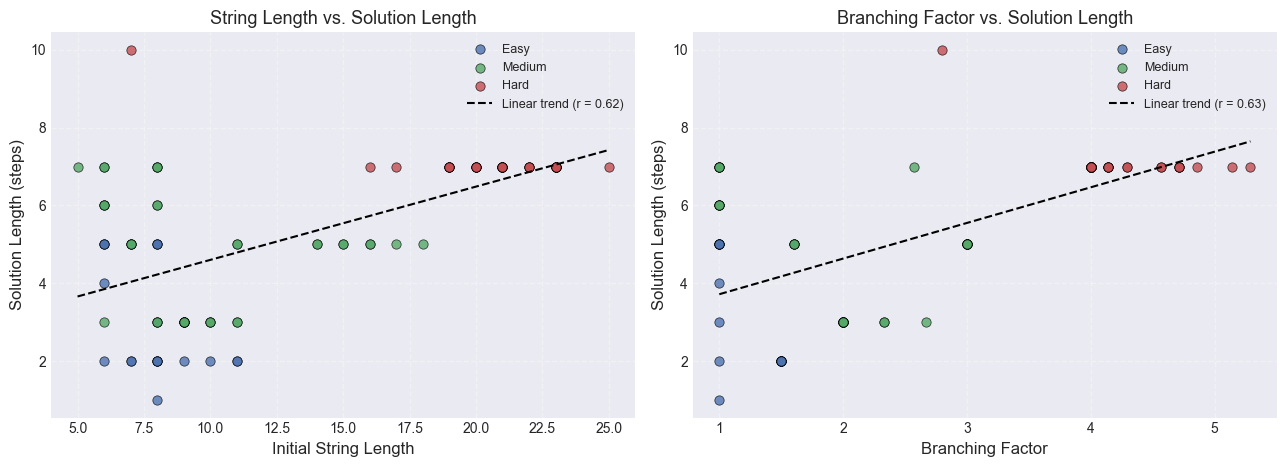

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Difficulty order and classic colors
difficulty_order = ['easy', 'medium', 'hard', 'expert']
DIFF_COLORS = {
    'easy':   '#4C72B0',  # muted blue
    'medium': '#55A868',  # muted green
    'hard':   '#C44E52',  # muted red
    'expert': '#8172B2'   # muted purple
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# -------------------------------------------------
# Scatter 1: String Length vs Solution Length
# -------------------------------------------------
for difficulty in difficulty_order:
    if difficulty in df['difficulty_level'].values:
        subset = df[df['difficulty_level'] == difficulty]
        axes[0].scatter(
            subset['string_length'],
            subset['solution_length'],
            label=difficulty.capitalize(),
            color=DIFF_COLORS[difficulty],
            s=45,
            alpha=0.8,
            edgecolor='black',
            linewidth=0.5
        )

# Trend line
x = df['string_length']
y = df['solution_length']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

axes[0].plot(
    np.sort(x),
    p(np.sort(x)),
    linestyle='--',
    color='black',
    linewidth=1.5,
    label=f"Linear trend (r = {x.corr(y):.2f})"
)

axes[0].set_title("String Length vs. Solution Length", fontsize=13)
axes[0].set_xlabel("Initial String Length")
axes[0].set_ylabel("Solution Length (steps)")
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].set_axisbelow(True)
axes[0].legend(fontsize=9, frameon=False)

# -------------------------------------------------
# Scatter 2: Branching Factor vs Solution Length
# -------------------------------------------------
for difficulty in difficulty_order:
    if difficulty in df['difficulty_level'].values:
        subset = df[df['difficulty_level'] == difficulty]
        axes[1].scatter(
            subset['branching_factor'],
            subset['solution_length'],
            label=difficulty.capitalize(),
            color=DIFF_COLORS[difficulty],
            s=45,
            alpha=0.8,
            edgecolor='black',
            linewidth=0.5
        )

# Trend line
x2 = df['branching_factor']
y2 = df['solution_length']
z2 = np.polyfit(x2, y2, 1)
p2 = np.poly1d(z2)

axes[1].plot(
    np.sort(x2),
    p2(np.sort(x2)),
    linestyle='--',
    color='black',
    linewidth=1.5,
    label=f"Linear trend (r = {x2.corr(y2):.2f})"
)

axes[1].set_title("Branching Factor vs. Solution Length", fontsize=13)
axes[1].set_xlabel("Branching Factor")
axes[1].set_ylabel("Solution Length (steps)")
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].set_axisbelow(True)
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()


# # Correlation summary
# print("\nKey Correlations:")
# corr_str_sol = df['string_length'].corr(df['solution_length'])
# corr_br_sol = df['branching_factor'].corr(df['solution_length'])
# corr_str_br = df['string_length'].corr(df['branching_factor'])
# print(f"  String Length ↔ Solution Length: {corr_str_sol:.3f}")
# print(f"  Branching Factor ↔ Solution Length: {corr_br_sol:.3f}")
# print(f"  String Length ↔ Branching Factor: {corr_str_br:.3f}")


Longer strings generally require more steps to solve — intuitively, more characters means more to remove. This makes string length a decent proxy for puzzle complexity, though the moderate correlation shows it's not the whole story. Some short strings need many steps (e.g., multi-phase puzzles where you transform before deleting), while some long strings can be cleared quickly (single large-chunk removals). The relationship holds on average, but puzzle structure matters more than raw length.

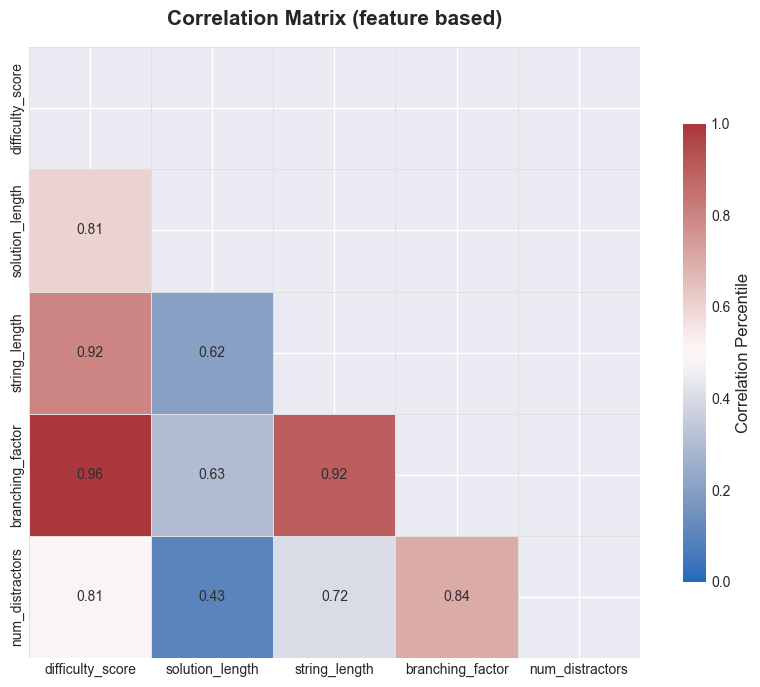

In [72]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# Copy correlation matrix
corr = correlation_matrix.copy()

# Mask upper triangle & diagonal
mask = np.triu(np.ones_like(corr, dtype=bool))

# Extract values used for coloring
vals = corr.values[~mask]

# Convert to percentiles (0–1)
percentiles = rankdata(vals, method="average") / len(vals)

# Create percentile matrix
perc_matrix = np.full_like(corr.values, np.nan, dtype=float)
perc_matrix[~mask] = percentiles
perc_matrix = pd.DataFrame(
    perc_matrix,
    index=corr.index,
    columns=corr.columns
)

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    perc_matrix,
    mask=mask,
    cmap=sns.color_palette("vlag", as_cmap=True),
    vmin=0, vmax=1,               # ← percentiles!
    square=True,
    linewidths=0.4,
    linecolor="#e0e0e0",
    annot=correlation_matrix,     # ← show TRUE values
    fmt=".2f",
    annot_kws={
        "size": 10,
        "color": "#2f2f2f"
    },
    cbar_kws={
        "shrink": 0.75,
        "label": "Correlation Percentile"
    },
    ax=ax
)

ax.set_title(
    "Correlation Matrix (feature based)",
    fontsize=15,
    fontweight="semibold",
    pad=16
)

plt.tight_layout()
plt.show()


## Dataset Summary 

The dataset consists of 100 structured reasoning problems generated using 8 distinct generator types, spanning three difficulty levels (Easy, Medium, Hard). The design emphasizes both diversity and controlled complexity, making it suitable for systematic evaluation of LLM reasoning behavior.

### Difficulty Distribution
The dataset is balanced toward medium and hard problems, ensuring sufficient challenge:

- Easy: 20% (Avg. difficulty score: 19.3)  
- Medium: 40% (Avg. difficulty score: 32.6)  
- Hard: 40% (Avg. difficulty score: 58.4)

This distribution avoids over-representation of trivial instances while maintaining a meaningful baseline for calibration.

### Generator Diversity
Eight generator types contribute to varied reasoning demands:

- Sequential reasoning: `backward_3`, `backward_5`, `backward_7`  
- Algorithmic reasoning: `sort_3`, `sort_4`  
- Pattern-based reasoning: `palin_3`, `concat_2`  
- Multi-phase reasoning: `multiphase`

Notably, the `backward_*` generators dominate the dataset (64%), providing a strong testbed for step-wise planning and reversibility reasoning, while smaller generator classes introduce structural heterogeneity.

### Complexity Characteristics
Key structural properties of the problems include:

- Solution length: 1–10 steps (mean: 5.3)  
- String length: 5–25 characters (mean: 13.7)  
- Branching factor: 1.00–5.29 (mean: 2.73)  
- Distractors present: 69% of problems

The presence of distractors in a majority of instances is critical for evaluating whether models rely on genuine reasoning rather than surface-level pattern matching.

### Implications for LLM Evaluation
This dataset is well-suited for **reasoning-centric evaluation**:

1. The controlled solution length range supports Chain-of-Thought (CoT) and step-wise evaluation.
2. Diverse generators test multiple reasoning modes, reducing overfitting to a single problem structure.
3. High distractor prevalence enables analysis of robustness against misleading actions.
4. The observed correlation between difficulty and structural complexity allows investigation of **metric identifiability** (e.g., progress vs. correctness).

Overall, the dataset provides a structured yet diverse benchmark for probing **latent reasoning competence** in large language models.
